# Spin Orbite model for 3d orbital
## Author: Mathieu Desmarais
### Date: 28-05-2026 

## Packages and modules

In [185]:
import numpy as np 
import qutip as qt                 # Package for quantum mecanic
import ufss as uf                  # Generation of doubled sided feynmann diagram
import matplotlib.pyplot as plt
from itertools import product

# 2. La spectroscopie 2D
from qudpy.Classes import System   # Calcul and generation of 2D plot
import qudpy.plot_functions as pf


## Physics constant and definition of parameter

In [186]:
hbar = 0.658211951 # hbar in eV*fs

## Useful Functions


In [187]:
#### Calcul of the dispersion for the spin-Peierls phases #####
def Spin_Peierls_dispersion(k, T, B, J, T_SP_0, delta_0, beta):
    alpha = 0.004
    T_SP = T_SP_0 * (1 - alpha * B**2)
    T_SP = max(0.0,T_SP)

    if T < T_SP: 
        delta = delta_0 * (1 - T/T_SP)**beta
    else: 
        delta=0

    #Cross-Fisher relation: the gap Delta scale like J* delta^(2/3)
    Delta = 2.0 * J * (delta **(2/3)) if delta > 0 else 0.0

    v = (np.pi * J) /2
    epsilon_k = np.sqrt(Delta**2 + (v * np.sin(k)**2))
    return epsilon_k

def get_coupling(k, eta=0.0, a_dimer=1.0, parity='odd'):
    """
    Calculates the effective SOC coupling for a dimerized lattice (e.g., CuGeO3).

    Parameters:
    -----------
    k : float
        Wave vector.
    eta : float
        Mixing parameter. Represents symmetry breaking due to lattice 
        fluctuations, magnetic frustration, or crystal field effects.
    a_dimer : float
        Relative distance between atoms in the dimer (normalized).
    parity : str
        'odd' (antisymmetric -> sin), 'even' (symmetric -> cos), or 'mixed'.

    Returns:
    --------
    float
        The effective coupling strength at wave vector k.
    """
    # The phase shift depends on the internal dimension of the dimer
    phase = k * (a_dimer / 2.0)
    
    if parity == 'odd':
        return np.sin(phase)
    elif parity == 'even':
        return np.cos(phase)
    else:
        # Arbitrary mixing if the crystal symmetry is broken
        return np.sin(phase) + eta * np.cos(phase)
    
def get_subspace_projector(dims, condition_func):
    """
    Construit le projecteur P pour un espace défini par 'dims'.
    condition_func(indices) doit retourner True si l'état est valide.
    """
    basis_subset = []
    
    # Génère toutes les combinaisons d'indices possibles pour la base complète
    # ex: pour dims=[3, 2, 2], product génère (0,0,0), (0,0,1), ..., (2,1,1)
    all_indices = product(*[range(d) for d in dims])
    
    for indices in all_indices:
        # Appliquer votre condition logique
        # 'indices' est un tuple, ex: (orb_idx, spin1_idx, spin2_idx, ...)
        if condition_func(indices):
            # Créer le vecteur de base complet correspondant
            ket = qt.tensor([qt.basis(d, i) for d, i in zip(dims, indices)])
            basis_subset.append(ket.full()) # On garde la forme numpy pour l'instant
    
    # Empiler les vecteurs colonnes pour former P (N_full x N_sub)
    if not basis_subset:
        raise ValueError("Aucun état ne satisfait la condition.")
        
    P_data = np.hstack(basis_subset)
    return qt.Qobj(P_data, dims=[dims, [len(basis_subset)]])



def simulate_dynamics_soc(valeurs_lambda_soc, n_modes, H_orb, dipole_op, L_op, ket_g, ket_d, ket_b, H_spin, annihilations_ops, k_values, tlist, c_ops):
    print(f"--- Préparation des Hamiltoniens de base (N_modes = {n_modes}) ---")
    
 

    Id_spin = qt.qeye(H_spin.shape[0])
    Id_orb = qt.qeye(H_orb.shape[0])


    ket_0_spin = qt.basis(Id_spin.shape[0], 0)
    psi0 = qt.tensor(ket_b, ket_0_spin)

    P_g_tot = qt.tensor(ket_g * ket_g.dag(), Id_spin)
    P_d_tot = qt.tensor(ket_d * ket_d.dag(), Id_spin)
    P_b_tot = qt.tensor(ket_b * ket_b.dag(), Id_spin)

    resultats = {}

    print("--- Début de la boucle de simulation ---")
    for lamda in valeurs_lambda_soc:
        print(f"Simulation en cours pour lambda_SOC = {lamda}...")
        
        H_tot, dipole_tot, lowering_op_tot = TotalHamiltonian(
            H_orb, dipole_op, L_op, H_spin, annihilations_ops, k_values, lambda_SOC=lamda, eta=0, a_dimer=1, parity="odd"
        )
        
        # --- LE CORRECTIF : Aplatissement de tous les opérateurs pour mesolve ---
        N_tot = H_tot.shape[0] # Vaudra 63 dans ton cas
        dims_op = [[N_tot], [N_tot]]
        dims_ket = [[N_tot], [1]]

        # 1. On uniformise l'Hamiltonien et l'état
        H_tot.dims = dims_op
        psi0.dims = dims_ket

        # 2. On uniformise les projecteurs
        P_g_tot.dims = dims_op
        P_d_tot.dims = dims_op
        P_b_tot.dims = dims_op

        # 3. On uniformise les opérateurs de Lindblad (c_ops)
        c_ops_flat = []
        for c in c_ops:
            c_copy = c.copy()
            c_copy.dims = dims_op
            c_ops_flat.append(c_copy)
        # ------------------------------------------------------------------------
        
        # Résolution de l'équation maîtresse avec les versions aplaties
        result = qt.mesolve(H_tot, psi0, tlist, c_ops=c_ops_flat, e_ops=[P_g_tot, P_d_tot, P_b_tot])
        
        pop_ground = result.expect[0]
        pop_dark = result.expect[1]
        pop_bright = result.expect[2]
        
        resultats[lamda] = {
            'ground': pop_ground,
            'dark': pop_dark,
            'bright': pop_bright
        }

        # Affichage Graphique
        plt.figure(figsize=(9, 5))
        plt.plot(tlist, pop_bright, label="Population (Bright State)", color="red", linewidth=2)
        plt.plot(tlist, pop_dark, label="Population (Dark State + Triplons)", color="blue", linewidth=2)
        plt.plot(tlist, pop_ground, label="Population (Ground State)", color="green", linewidth=2)
        plt.plot(tlist, pop_bright + pop_dark + pop_ground, label="Population Totale (Conservation)", color="black", linestyle="--")

        plt.xlabel("Temps")
        plt.ylabel("Probabilité")
        plt.title(f"Dynamique de transfert SOC ($\\lambda_{{SOC}}$ = {lamda}, $N_{{modes}}$ = {n_modes})")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    print("--- Simulations terminées ---")
    return resultats


## Hamiltonian Definition

In [188]:
def BuildOrbitalHamiltonian(Delta_dark, Delta_bright):
    """
    Construction of the orbital sector (ground, Bright, Dark).
    """
    ket_g = qt.basis(3, 0) # |ground>
    ket_d = qt.basis(3, 1) # |dark>
    ket_b = qt.basis(3, 2) # |bright>

    # Energy projection operators
    P_d = ket_d * ket_d.dag()
    P_b = ket_b * ket_b.dag()  
    P_g = ket_g * ket_g.dag()  

    # Orbital Hamiltonian (sets energy levels for excited states)
    H_orb = Delta_dark * P_d + Delta_bright * P_b
    a_b_local = ket_g * ket_b.dag() + ket_b * ket_g.dag() # Local coupling between g and b 
    a_d_local = ket_g * ket_d.dag() + ket_d * ket_g.dag()

    # Dipolar Operator (Light-matter coupling: pump excites g -> b)
    dipole_op_bright = ket_g * ket_b.dag() + ket_b * ket_g.dag()
    dipole_op_dark = ket_g * ket_d.dag() + ket_d * ket_g.dag()

    # Orbital operator for Spin-Orbit Coupling (SOC) (Mixes b <-> d)
    L_op = ket_d * ket_b.dag() + ket_b * ket_d.dag() 

    return H_orb, dipole_op_bright, dipole_op_dark, L_op, ket_g, ket_d, ket_b

def BuildKSpaceSpinHamiltonian(N_modes, T, B, J, T_SP_0, delta_0, beta, max_bosons_per_mode=2, max_total_triplons=1):
    """
    Constructs the triplon sector in k-space.
    Uses 'enr_destroy' to restrict the Hilbert space size for efficiency.
    """
    # Brillouin Zone discretization
    k_values = np.linspace(-np.pi, np.pi, N_modes)
    epsilon_k = [Spin_Peierls_dispersion(k, T, B, J, T_SP_0, delta_0, beta) for k in k_values]
    
    # Dimensions defined by max bosons allowed per mode
    dims = [max_bosons_per_mode] * N_modes
    
    # Energy-Restricted (ENR) annihilation operators
    # If max_total_triplons = 1, the matrix size is linear (N_modes + 1) instead of 2^N
    
    annihilation_ops = []
    H_spin = 0
    for i in range(N_modes): 
        
        op_list = [qt.qeye(max_bosons_per_mode) for _ in range (N_modes)]
        op_list[i] = qt.destroy(max_bosons_per_mode)
        annihilation_ops.append(qt.tensor(op_list))
        a_global = annihilation_ops[i]
        H_spin += epsilon_k[i] * a_global.dag() * a_global


    


    return H_spin, annihilation_ops, k_values

def TotalHamiltonian(H_orb, dipole_op, L_op, H_spin_k, annihilations_ops, k_values, Threshold=1e-6, 
                     lambda_SOC=0.01, eta=0.0, a_dimer=1.0, parity='odd'):
    
    Id_orb = qt.qeye(H_orb.dims[0])
    Id_spin = qt.qeye(H_spin_k.dims[0])
    #Id_spin = qt.Qobj(np.eye(H_spin_k.shape[0]), dims=H_spin_k.dims)

    H_orb_tot = qt.tensor(H_orb, Id_spin)
    H_spin_tot = qt.tensor(Id_orb, H_spin_k)



    H_spin_tot.dims = H_orb_tot.dims

    H_SOC_tot = 0
    for i, k in enumerate(k_values):
        a_k = annihilations_ops[i]
        
        # Calling the coupling function
        V_k = get_coupling(k, eta=eta, a_dimer=a_dimer, parity=parity)
        
        S_op_k = V_k * (a_k + a_k.dag())
        H_SOC_term = qt.tensor(L_op, S_op_k)
        H_SOC_term.dims = H_orb_tot.dims
        H_SOC_tot += lambda_SOC * H_SOC_term

    # Combine and finalize



    
    H_tot = H_orb_tot + H_spin_tot + H_SOC_tot

    ket_g = qt.basis(3, 0) # |ground>
    ket_d = qt.basis(3, 1) # |dark>
    ket_b = qt.basis(3, 2) # |bright>

    dipole_operator = ket_g * ket_b.dag() + ket_b * ket_g.dag()
    dipole_operator = qt.tensor(dipole_operator, Id_spin)
    dipole_operator = dipole_operator.tidyup(atol=Threshold)

    lowering_op = ket_g * ket_b.dag()
    lowering_op = qt.tensor(lowering_op, Id_spin)
    lowering_op = lowering_op.tidyup(atol=Threshold)

    
    dipole_tot = qt.tensor(dipole_op, Id_spin)
   
    return H_tot, lowering_op, dipole_operator  
"""


def TotalHamiltonian(H_orb, dipole_op, L_op, H_spin_k, annihilations_ops, k_values, Threshold=1e-6, 
                     lambda_SOC=0.01, eta=0.0, a_dimer=1.0, parity='odd'):
    
    
    Id_orb = qt.qeye(H_orb.dims[0])
    Id_spin = qt.qeye(H_spin_k.dims[0])

    H_orb_tot = qt.tensor(H_orb, Id_spin)
    H_spin_tot = qt.tensor(Id_orb, H_spin_k)

    H_SOC_tot = 0
    for i, k in enumerate(k_values):
        a_k = annihilations_ops[i]
        
        # Calling the coupling function
        V_k = get_coupling(k, eta=eta, a_dimer=a_dimer, parity=parity)
        
        S_op_k = V_k * (a_k + a_k.dag())
        H_SOC_term = qt.tensor(L_op, S_op_k)
        
        H_SOC_tot += lambda_SOC * H_SOC_term

    # FIX 2: Force QuTiP to recognize the identical structures right before addition.
    # This completely bypasses the strict numpy/tuple/list type checker.
    common_dims = H_orb_tot.dims
    H_spin_tot.dims = common_dims
    if isinstance(H_SOC_tot, qt.Qobj):
        H_SOC_tot.dims = common_dims

        
    # Combine and finalize
    H_tot = H_orb_tot + H_spin_tot + H_SOC_tot

    ket_g = qt.basis(3, 0) # |ground>
    ket_d = qt.basis(3, 1) # |dark>
    ket_b = qt.basis(3, 2) # |bright>

    lowering_op = ket_g * ket_b.dag() + ket_b * ket_g.dag()
    lowering_op_tot = qt.tensor(lowering_op, Id_spin)
    lowering_op_tot = lowering_op_tot.tidyup(atol=Threshold)
    
    dipole_tot = qt.tensor(dipole_op, Id_spin)
    H_tot.dims = [[H_tot.shape[0]], [H_tot.shape[0]]]
    dipole_tot.dims = [[dipole_tot.shape[0]], [dipole_tot.shape[0]]]
    return H_tot, dipole_tot, lowering_op_tot
"""


"\n\n\ndef TotalHamiltonian(H_orb, dipole_op, L_op, H_spin_k, annihilations_ops, k_values, Threshold=1e-6, \n                     lambda_SOC=0.01, eta=0.0, a_dimer=1.0, parity='odd'):\n\n\n    Id_orb = qt.qeye(H_orb.dims[0])\n    Id_spin = qt.qeye(H_spin_k.dims[0])\n\n    H_orb_tot = qt.tensor(H_orb, Id_spin)\n    H_spin_tot = qt.tensor(Id_orb, H_spin_k)\n\n    H_SOC_tot = 0\n    for i, k in enumerate(k_values):\n        a_k = annihilations_ops[i]\n\n        # Calling the coupling function\n        V_k = get_coupling(k, eta=eta, a_dimer=a_dimer, parity=parity)\n\n        S_op_k = V_k * (a_k + a_k.dag())\n        H_SOC_term = qt.tensor(L_op, S_op_k)\n\n        H_SOC_tot += lambda_SOC * H_SOC_term\n\n    # FIX 2: Force QuTiP to recognize the identical structures right before addition.\n    # This completely bypasses the strict numpy/tuple/list type checker.\n    common_dims = H_orb_tot.dims\n    H_spin_tot.dims = common_dims\n    if isinstance(H_SOC_tot, qt.Qobj):\n        H_SOC_tot.dims

## Note 

H_orb_tot becomes a tensor of [ComplexSpace(3), ComplexSpace(2)].

H_spin_tot becomes a tensor of [ComplexSpace(3), FockSpace(2)].

When I try  to add them via H_orb_tot + H_spin_tot, QuTip sees that CompelxSpace != FockSpace, reject the addition, and prints a widly unhelpful error message.

To resolve this, we need to deliberately override the .dims property of the components before adding them together

## Dissipation (Lindblad Operator)

In [189]:
N_modes=1
T=5
T_SP_0 = 14
B=0
J=1
delta_0= 0.01
beta= 0.5
Lamda_SOC = 0.20
max_bosons_per_mode = 2
E_d = 0.90
E_B = 1.0



H_orb, dipole_op_bright, dipole_op_dark, L_op, ket_g, ket_d, ket_b = BuildOrbitalHamiltonian(E_d, E_B)
H_spin, annihilation_ops, k_values = BuildKSpaceSpinHamiltonian(N_modes, T, B, J, T_SP_0, delta_0, beta)



H_tot, lowering_operator, dipole_operator = TotalHamiltonian(H_orb, dipole_op_bright, L_op, H_spin, annihilation_ops, k_values)



def mon_critere_physique(indices):
    excitations_spin = sum(indices[1:]) # Somme des indices des modes
    return excitations_spin <= 1

P= get_subspace_projector(H_tot.dims[0], mon_critere_physique)




H_tot_trunk =P.dag() *H_tot * P






## Some test and print on the Hamiltonian

In [190]:
#print(H_tot)
print(H_tot_trunk)
#print(H_orb)
#print(H_spin)


Lamda_SOC_test = [0.05,0.1, 0.2]

tlist_test = np.linspace(0, 1000, 1000)
relax_op = ket_d * ket_b.dag()
gamma_relaxation = 0.001
Id_spin = qt.qeye(H_spin.shape[0])
c_ops = [np.sqrt(gamma_relaxation) * qt.tensor(relax_op, Id_spin)]



# Appel de la fonction (elle utilisera les variables globales T, B, J, E_d, etc. définies ailleurs dans ton script)
#donnees_populations = simulate_dynamics_soc(Lamda_SOC_test, N_modes,H_orb,dipole_tot, L_op, ket_g, ket_d, ket_b ,H_spin,annihilation_ops, k_values, tlist_test, c_ops)


Quantum object: dims=[[6], [6]], shape=(6, 6), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.08011887  0.          0.          0.          0.        ]
 [ 0.          0.          0.9         0.          0.         -0.01      ]
 [ 0.          0.          0.          0.98011887 -0.01        0.        ]
 [ 0.          0.          0.         -0.01        1.          0.        ]
 [ 0.          0.         -0.01        0.          0.          1.08011887]]


In [191]:
def build_collapse_operators(ket_g, ket_b, annihilations_ops, gamma_orb, gamma_spin, dims_orb, dims_spin):
    """
    Construit la liste des opérateurs de Lindblad (c_ops) pour le système couplé.
    dims_orb: Liste des dimensions orbitales (ex: [3])
    dims_spin: Liste des dimensions de spin (ex: [2, 2] pour 2 modes)
    """
    c_ops = []
    
    # 0. Création des opérateurs Identité avec la bonne structure tensorielle
    # qt.qeye([2, 2]) crée automatiquement la structure dims=[[2,2], [2,2]]
    I_spin = qt.qeye(dims_spin)
    I_orb = qt.qeye(dims_orb)
    
    # --- 1. Orbital Relaxation ---
    # L'électron descend de Bright à Ground
    decay_orb = ket_g * ket_b.dag()
    
    # Le produit tensoriel assemble [3] et [2, 2] en [3, 2, 2] naturellement
    c_orb_tot = qt.tensor(decay_orb, I_spin)
    c_ops.append(np.sqrt(gamma_orb) * c_orb_tot)
    
    # --- 2. Triplon Relaxation (3D effect / Decoherence) ---
    # Applique un taux de perte sur CHAQUE mode k
    for a_k in annihilations_ops:
        # a_k est déjà dans l'espace de spin total (dims=[[2, 2], [2, 2]])
        c_spin_tot = qt.tensor(I_orb, a_k)
        c_ops.append(np.sqrt(gamma_spin) * c_spin_tot)
        
    return c_ops

gamma_orb = 0.05   # Taux de recombinaison électronique
gamma_spin = 0.02  # Taux de perte/diffusion des triplons (élargissement de raie 3D)
c_ops_tot = build_collapse_operators(ket_g, ket_b, annihilation_ops, gamma_orb, gamma_spin, H_orb.dims[0], H_spin.dims[0])


## Density Matrix 

In [192]:
ket_fondamental = qt.basis(H_tot_trunk.shape[0], 0)

# On convertit ce vecteur pur en matrice de densité (|psi><psi|)
rho_0 = qt.ket2dm(ket_fondamental)



## Impulsion sequence

In [193]:

c_ops_reduced = [P.dag() * c_op * P for c_op in c_ops_tot]
a_reduced = P.dag() * lowering_operator * P
dipole_operator_reduced = P.dag() * dipole_operator *P

print(a_reduced)
print(dipole_operator_reduced)

sys = System(H=H_tot_trunk, rho=rho_0, a=a_reduced, u=dipole_operator_reduced, c_ops=c_ops_reduced, diagonalize=False)

"""
a is supposed to be the upper operator

u is the observable we want to trace, 

"""


# Setting up time delays (in femtoseconds)
# To resolve a 103 fs phonon, we sample over approximately 300 fs

res_fs = 3 # Time resolution (3 fs step)
N_t1 = 100 # Number of steps during the t1 delay (total = 300 fs)
N_t3 = 100 # Number of steps during the t3 detection (total = 300 fs)
t2_attente = 0 # Population time (T) set to 0 fs to start

time_delays = [N_t1, t2_attente, N_t3]
scan_id = [0, 2] # We perform the Fourier transform on t1 (index 0) and t3 (index 2)

Quantum object: dims=[[6], [6]], shape=(6, 6), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
Quantum object: dims=[[6], [6]], shape=(6, 6), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
system initialized


## Feynmann Diagram

In [194]:
DG = uf.DiagramGenerator
R3rd = DG()
dummy_times = [0, 100, 200, 300]
t_pulse = np.array([-1, 1])
R3rd.efield_times = [t_pulse] * 4

# --- 1. Diagrammes Rephasing (R1, R2, R3) ---
# Phase discrimination pour k_I = -k1 + k2 + k3
R3rd.set_phase_discrimination([(0, 1), (1, 0), (1, 0)])
[R3, R1, R2] = R3rd.get_diagrams(dummy_times)
rephasing = [R1, R2, R3]

# --- 2. Diagrammes Non-Rephasing (R4, R5, R6) ---
# Phase discrimination pour k_II = +k1 - k2 + k3
R3rd.set_phase_discrimination([(1, 0), (0, 1), (1, 0)])
[R6, R4, R5] = R3rd.get_diagrams(dummy_times)
nonrephasing = [R4, R5, R6]
response_list = []
total_diagrams = rephasing + nonrephasing

## Dynamic calcul

In [195]:
print("Calcul de la dynamique quantique en cours...")
for k in range(6):
    # L'argument r=res_fs dicte le pas temporel à la librairie
    states, t1, t2, dipole = sys.coherence2d(time_delays, total_diagrams[k], scan_id, r=res_fs, parallel=False)
    response_list.append(1j * dipole)

Calcul de la dynamique quantique en cours...
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors


C:\Users\MathieuDesmarais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors
second scan done


## Fourier Transform

In [196]:
spectra_list, extent, f1, f2 = sys.spectra(response_list, resolution=res_fs)

## Signal extraction

In [197]:
rephasing_spectra = spectra_list[:3]
rephasing_spectra.append(np.sum(spectra_list[:3], 0)) # La somme donne le signal Rephasing macroscopique

nonrephasing_spectra = spectra_list[3:]
nonrephasing_spectra.append(np.sum(spectra_list[3:], 0))

## 2D spectra plot

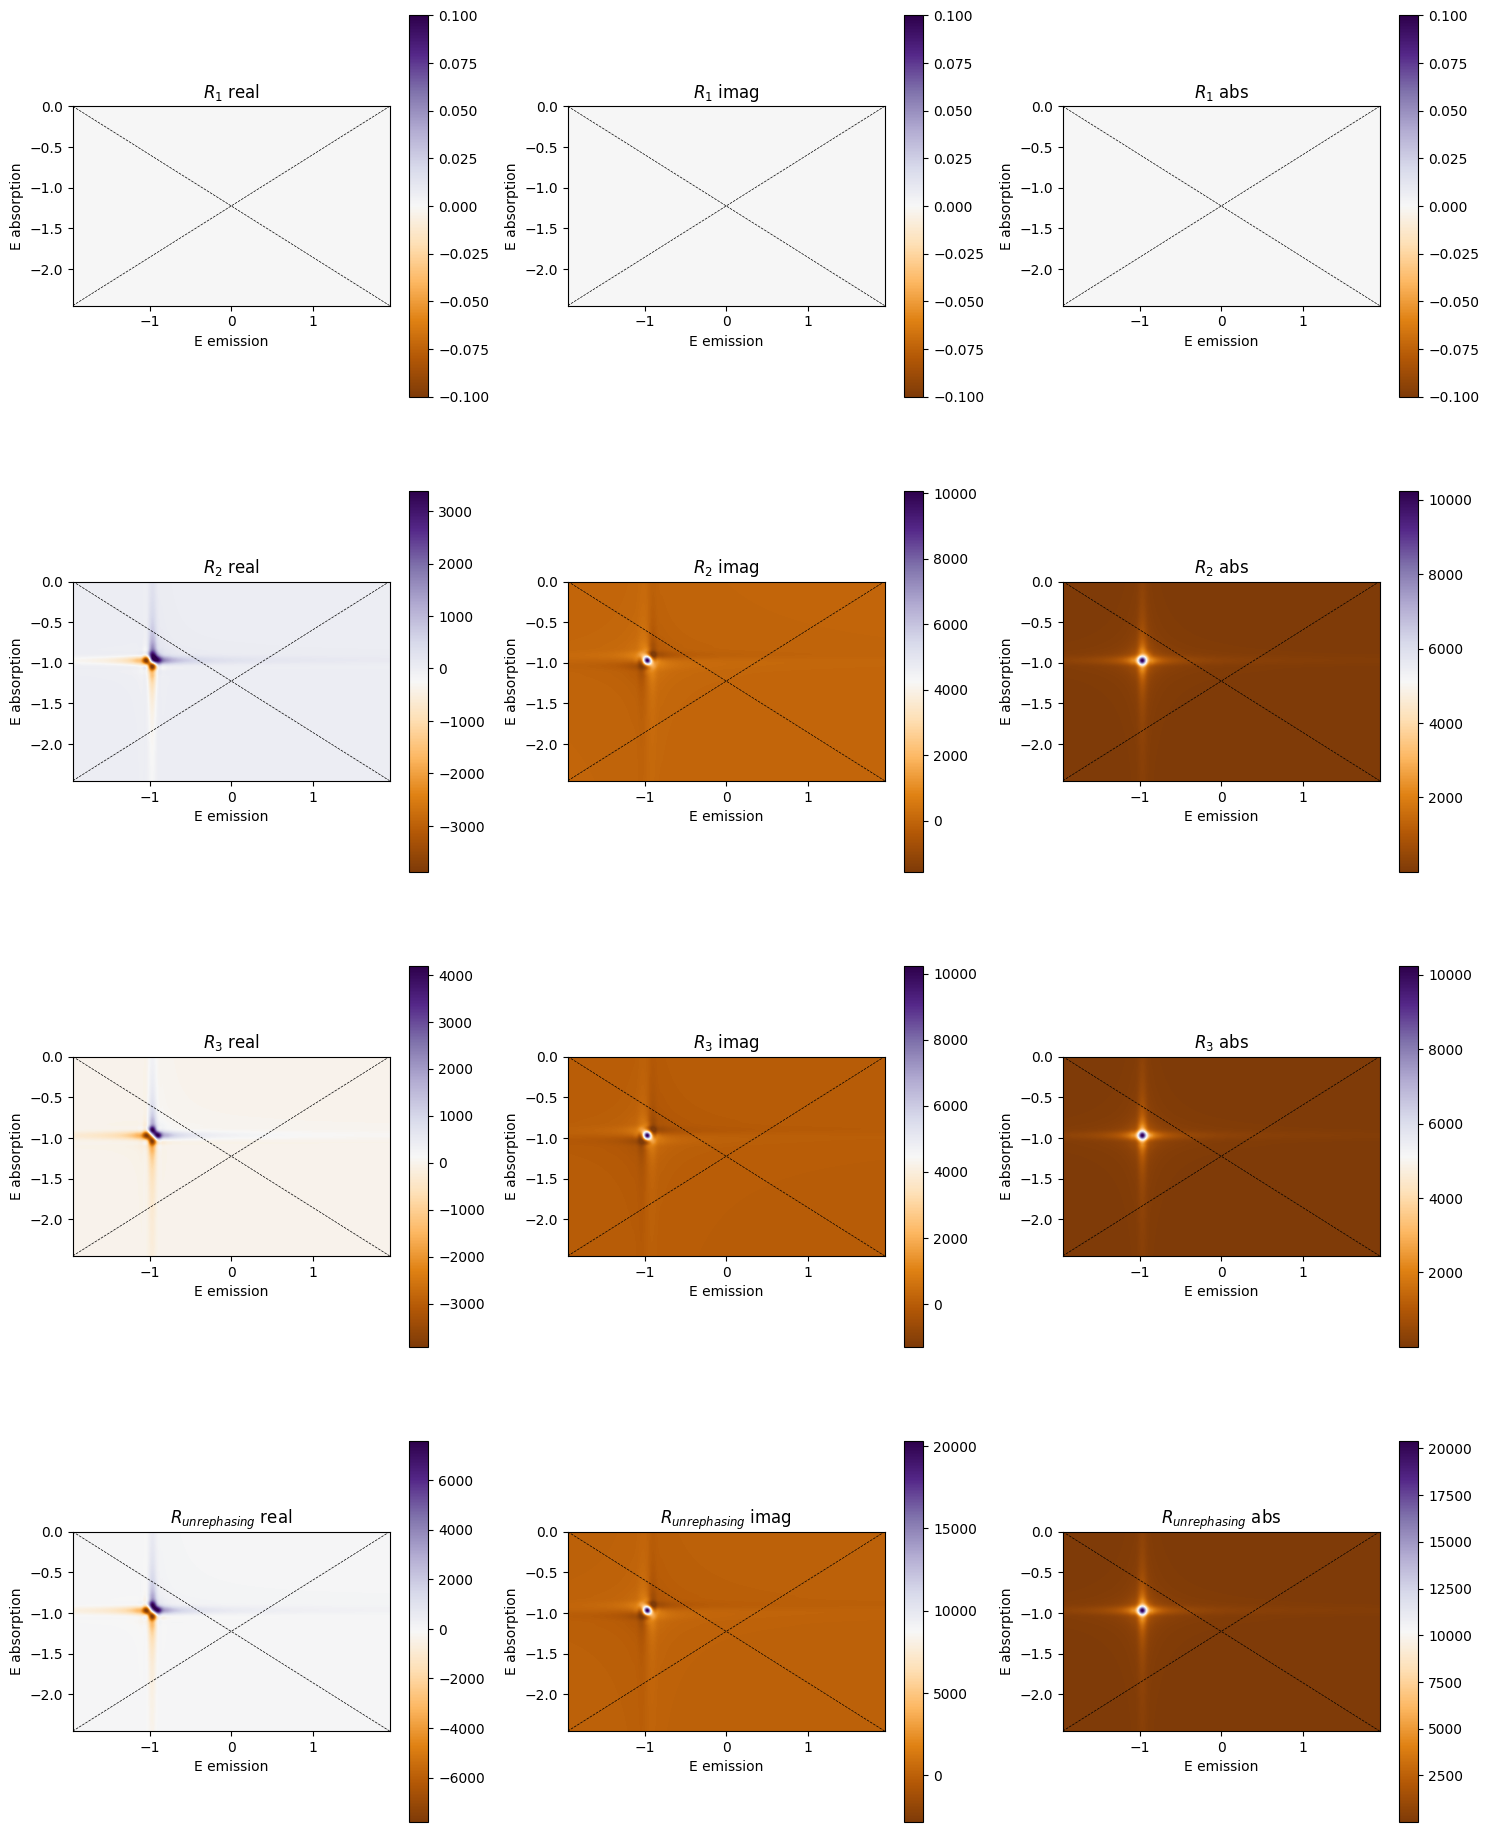

In [198]:
pf.silva_plot(nonrephasing_spectra, f1,f2, labels=['E emission', 'E absorption'],
              title_list=['$R_1$', '$R_2$', '$R_3$', '$R_{unrephasing}$'], scale='linear', color_map='PuOr',
              interpolation='spline36', center_scale=False, plot_sum=False, plot_quadrant='Zoom', invert_y=False,
              diagonals=[True, True],Zoom_coor = [-2,2,-2.5,0])

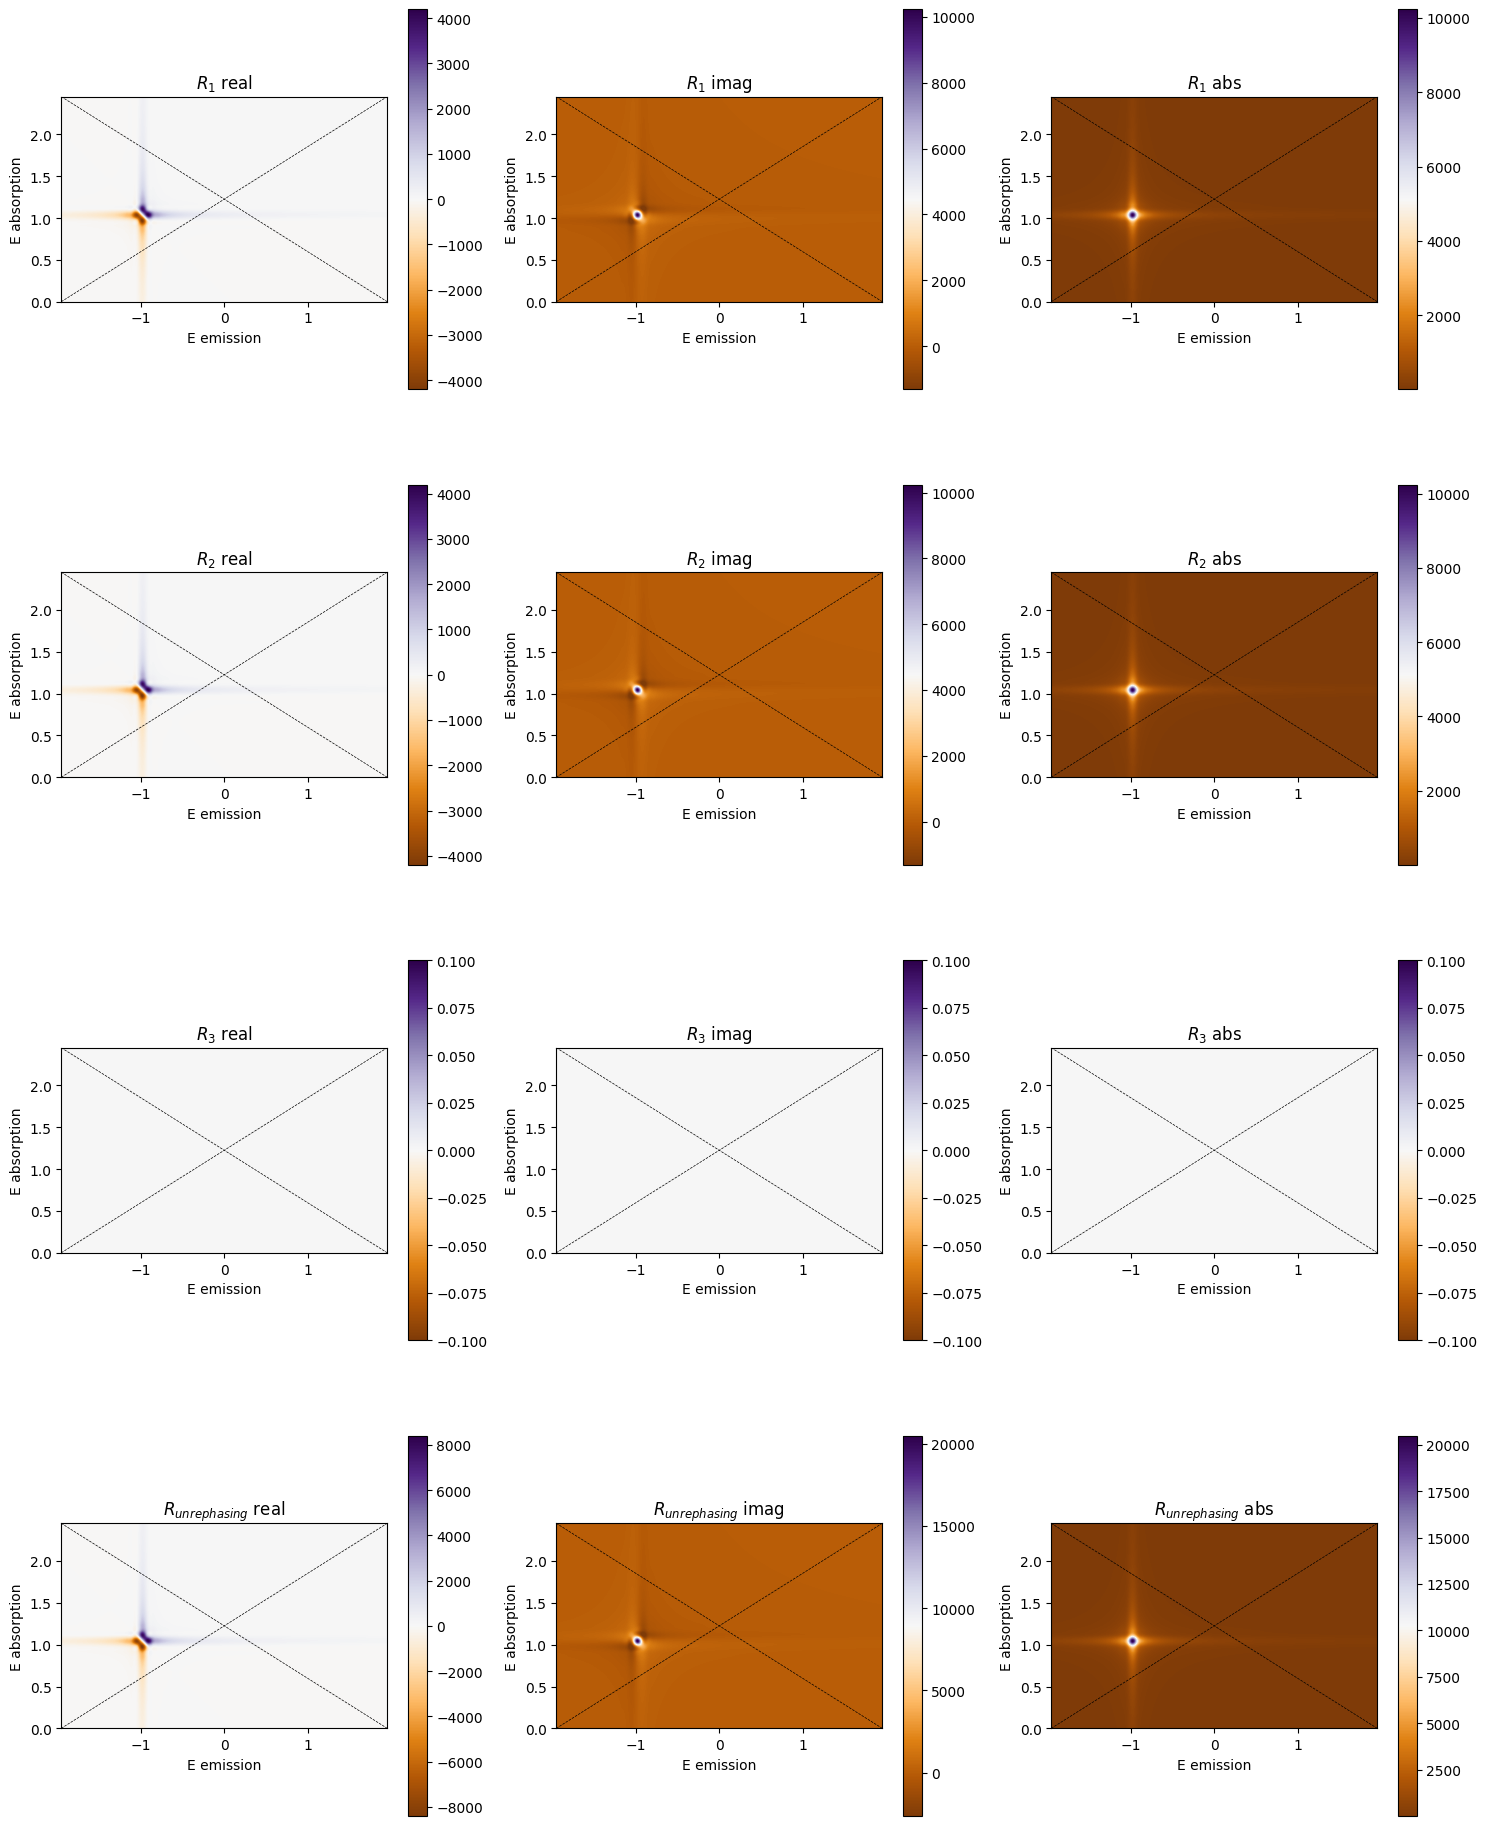

"\npf.silva_plot(rephasing_spectra, f1,f2, labels=['E emission', 'E absorption'],\n              title_list=['$R_1$', '$R_2$', '$R_3$', '$R_{rephasing}$'], scale='linear', color_map='PuOr',\n              interpolation='spline36', center_scale=False, plot_sum=False, plot_quadrant='All', invert_y=False,\n              diagonals=[True, True])\n"

In [199]:

pf.silva_plot(rephasing_spectra, f1,f2, labels=['E emission', 'E absorption'],
              title_list=['$R_1$', '$R_2$', '$R_3$', '$R_{unrephasing}$'], scale='linear', color_map='PuOr',
              interpolation='spline36', center_scale=False, plot_sum=False, plot_quadrant='Zoom', invert_y=False,
              diagonals=[True, True],Zoom_coor = [-2,2,0,2.5])
"""
pf.silva_plot(rephasing_spectra, f1,f2, labels=['E emission', 'E absorption'],
              title_list=['$R_1$', '$R_2$', '$R_3$', '$R_{rephasing}$'], scale='linear', color_map='PuOr',
              interpolation='spline36', center_scale=False, plot_sum=False, plot_quadrant='All', invert_y=False,
              diagonals=[True, True])
"""